
载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




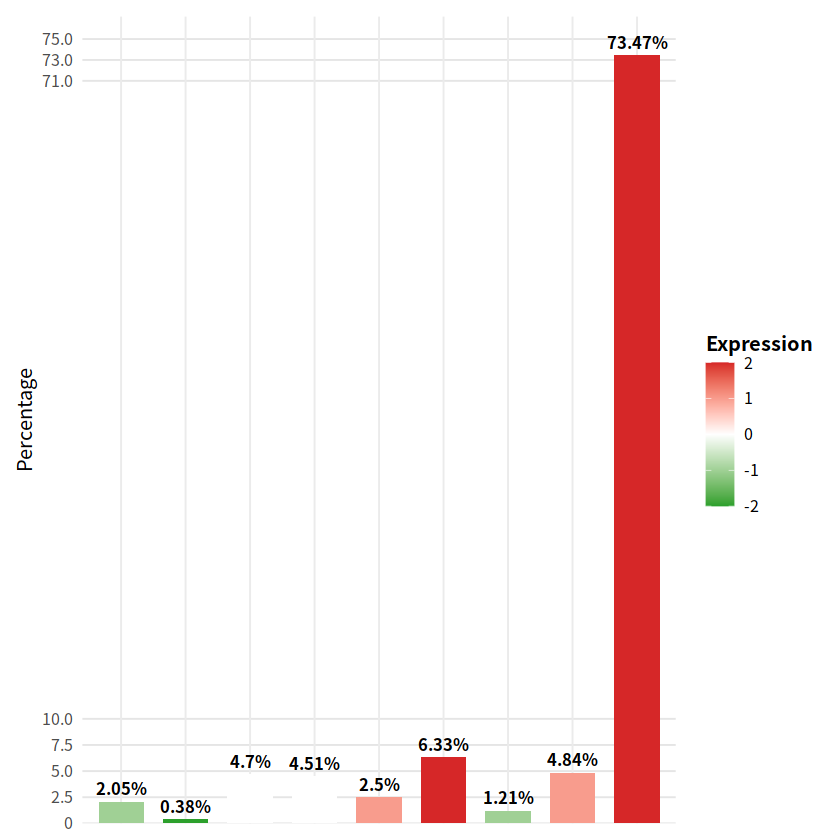

In [1]:
library(ggplot2)
library(dplyr)

# 构造数据（根据你的图中的百分比和 Expression 颜色推断）
# 假设 X 轴有 9 个类别，对应 9 个柱子
data <- data.frame(
  Category = factor(1:9, levels = 1:9),  # 无名类别
  Percentage = c(2.05, 0.38, 4.7, 4.51, 2.5, 6.33, 1.21, 4.84, 73.47),
  Expression = c(-1, -2, 0, 0, 1, 2, -1, 1, 2)  # 根据颜色大致推断
)

# 定义自定义 Y 轴断点和标签（模拟断裂轴）
y_breaks <- c(0, 2.5, 5.0, 7.5, 10.0, 71.0, 73.0, 75.0)
y_labels <- c("0", "2.5", "5.0", "7.5", "10.0", "71.0", "73.0", "75.0")

# 绘图
p <- ggplot(data, aes(x = Category, y = Percentage, fill = Expression)) +
  geom_col(width = 0.7) +  # 柱子宽度
  geom_text(aes(label = paste0(round(Percentage, 2), "%")), 
            vjust = -0.5, size = 3.5, fontface = "bold") +  # 百分比标签
  scale_fill_gradientn(
    colors = c("#2ca02c", "#ffffff", "#d62728"),  # 绿->白->红，匹配原图
    limits = c(-2, 2),
    breaks = c(-2, -1, 0, 1, 2),
    labels = c("-2", "-1", "0", "1", "2"),
    name = "Expression"
  ) +
  scale_y_continuous(
    breaks = y_breaks,
    labels = y_labels,
    expand = expansion(mult = c(0, 0.05))  # 上下留白
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_blank(),  # 隐藏 X 轴标签
    axis.ticks.x = element_blank(),
    panel.grid.major.y = element_line(color = "gray90"),
    panel.grid.minor = element_blank(),
    legend.position = "right",
    legend.title = element_text(face = "bold"),
    plot.margin = margin(10, 10, 10, 10)
  ) +
  labs(y = "Percentage")

# 显示图形
print(p)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.2
✔ readr     2.1.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette Set3 is 12
Returning the palette you asked for with that many colors
”
Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette Set3 is 12
Returning the palette you asked for with that many colors
”


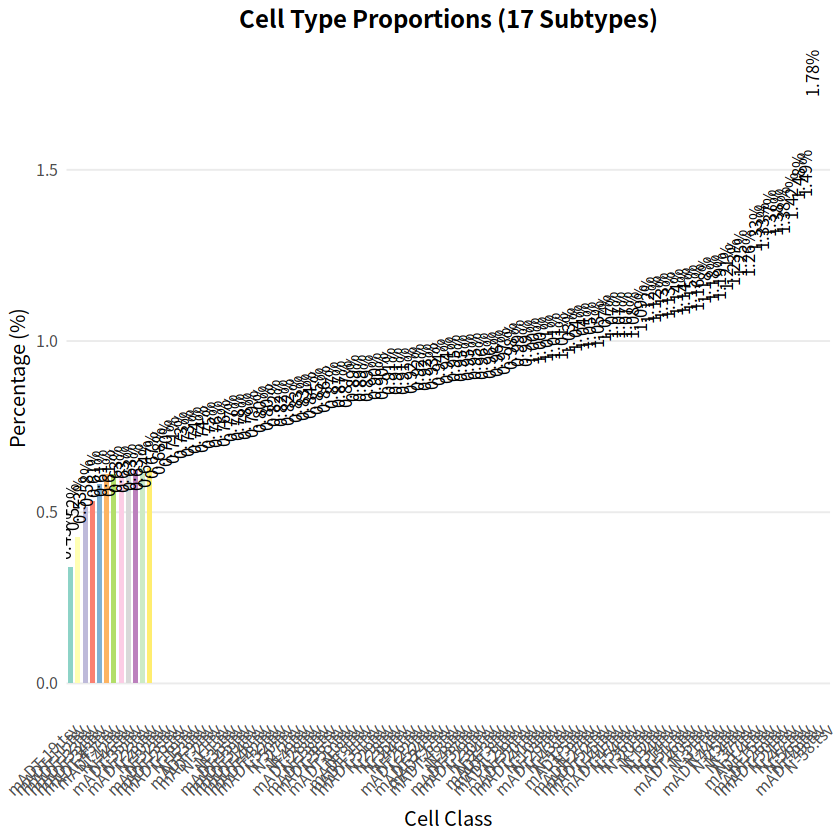

In [2]:
# 加载必要的包 (如果未安装，请先运行 install.packages("tidyverse"))
library(tidyverse)

# 1. 设置文件路径
file_path <- "/home/qyyuan/project/Lifei-Spatial/analysis/Part_2_discovery_cohort_CN_definition/Allsubtypes.csv"

# 2. 读取数据
# 假设文件有表头，如果没有请设置 header = FALSE
df <- read.csv(file_path, stringsAsFactors = FALSE, check.names = FALSE)

# 检查 Class 列是否存在
if (!"Class" %in% colnames(df)) {
  stop("错误：文件中未找到 'Class' 列。请检查列名是否正确。")
}

# 3. 数据处理：计算每个类别的计数和比例
plot_data <- df %>%
  count(Class) %>%  # 统计每个 Class 的数量 (n)
  mutate(
    Percentage = n / sum(n) * 100, # 计算百分比
    Class = factor(Class, levels = Class[order(n)]) # 按数量从小到大排序因子水平
  )

# 4. 绘图
p <- ggplot(plot_data, aes(x = Class, y = Percentage, fill = Class)) +
  geom_col(show.legend = FALSE, width = 0.7) +  # 绘制柱子，隐藏图例（因为X轴已有标签）
  
  # 添加百分比标签
  geom_text(aes(label = sprintf("%.2f%%", Percentage)), 
            vjust = -0.5, size = 3.5, angle = 90, color = "black") +
  
  # 坐标轴和标签设置
  labs(
    title = "Cell Type Proportions (17 Subtypes)",
    x = "Cell Class",
    y = "Percentage (%)"
  ) +
  
  # 主题美化
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1), # X轴标签倾斜45度
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    plot.title = element_text(hjust = 0.5, face = "bold")
  ) +
  
  # 颜色设置 (可选：使用 viridis 或 RColorBrewer 配色，这里使用默认渐变色)
  scale_fill_brewer(palette = "Set3") 

# 5. 显示图形
print(p)

# 6. (可选) 保存高清图片到当前目录
ggsave("cell_type_proportions.png", plot = p, width = 10, height = 6, dpi = 300)

检测到最后一列的列名为: Allsubtypes

Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette Set3 is 12
Returning the palette you asked for with that many colors
”
Warning message in RColorBrewer::brewer.pal(n, pal):
“n too large, allowed maximum for palette Set3 is 12
Returning the palette you asked for with that many colors
”
图形已保存为 cell_subtype_proportions.png



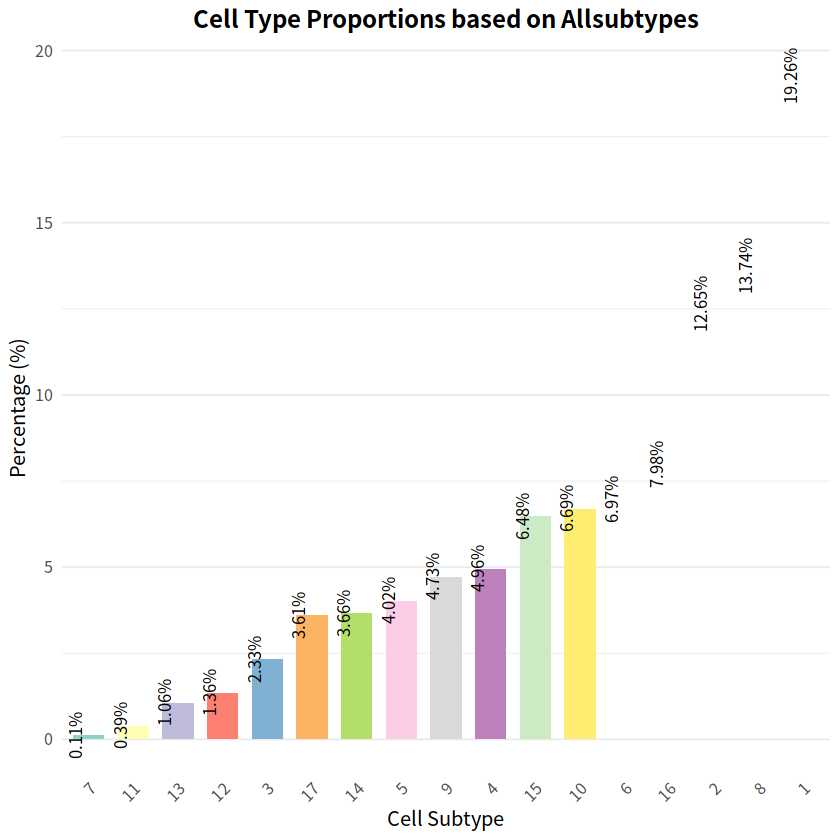

In [3]:
# 加载必要的包
library(tidyverse)

# 1. 设置文件路径
file_path <- "/home/qyyuan/project/Lifei-Spatial/analysis/Part_2_discovery_cohort_CN_definition/Allsubtypes.csv"

# 2. 读取数据
# check.names = FALSE 防止列名被自动修改
df <- read.csv(file_path, stringsAsFactors = FALSE, check.names = FALSE)

# 3. 自动获取最后一列的列名
last_col_name <- colnames(df)[ncol(df)]
message(paste("检测到最后一列的列名为:", last_col_name))

# 4. 数据处理：计算比例
# 使用 !!sym() 动态引用最后一列的列名
plot_data <- df %>%
  count(!!sym(last_col_name)) %>%  # 统计最后一列每个类别的数量
  rename(Class = !!sym(last_col_name)) %>% # 重命名为 Class 方便后续处理
  mutate(
    Percentage = n / sum(n) * 100,
    Class = factor(Class, levels = Class[order(n)]) # 按数量排序
  )

# 5. 绘图
p <- ggplot(plot_data, aes(x = Class, y = Percentage, fill = Class)) +
  geom_col(show.legend = FALSE, width = 0.7) +
  
  # 添加百分比标签 (如果柱子太矮，标签会自动调整位置或隐藏，这里设为顶部)
  geom_text(aes(label = sprintf("%.2f%%", Percentage)), 
            vjust = -0.5, size = 3.5, angle = 90, color = "black") +
  
  labs(
    title = paste("Cell Type Proportions based on", last_col_name),
    x = "Cell Subtype",
    y = "Percentage (%)"
  ) +
  
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1), # X轴标签倾斜
    panel.grid.major.x = element_blank(),
    plot.title = element_text(hjust = 0.5, face = "bold")
  ) +
  
  # 使用 Set3 配色表，适合多类别
  scale_fill_brewer(palette = "Set3")

# 6. 显示图形
print(p)

# 7. 保存图片
ggsave("cell_subtype_proportions.png", plot = p, width = 12, height = 7, dpi = 300)
message("图形已保存为 cell_subtype_proportions.png")

载入需要的程辑包：ggsci

✅ 成功读取文件。检测到细胞类别列为: Allsubtypes

📊 总细胞数: 1717465

🧬 细胞类别数量: 17

Warning message:
“This manual palette can handle a maximum of 10 values. You have supplied 17”
Warning message:
“This manual palette can handle a maximum of 10 values. You have supplied 17”
🎉 绘图完成！图片已保存为: cell_type_proportions_17subtypes.png



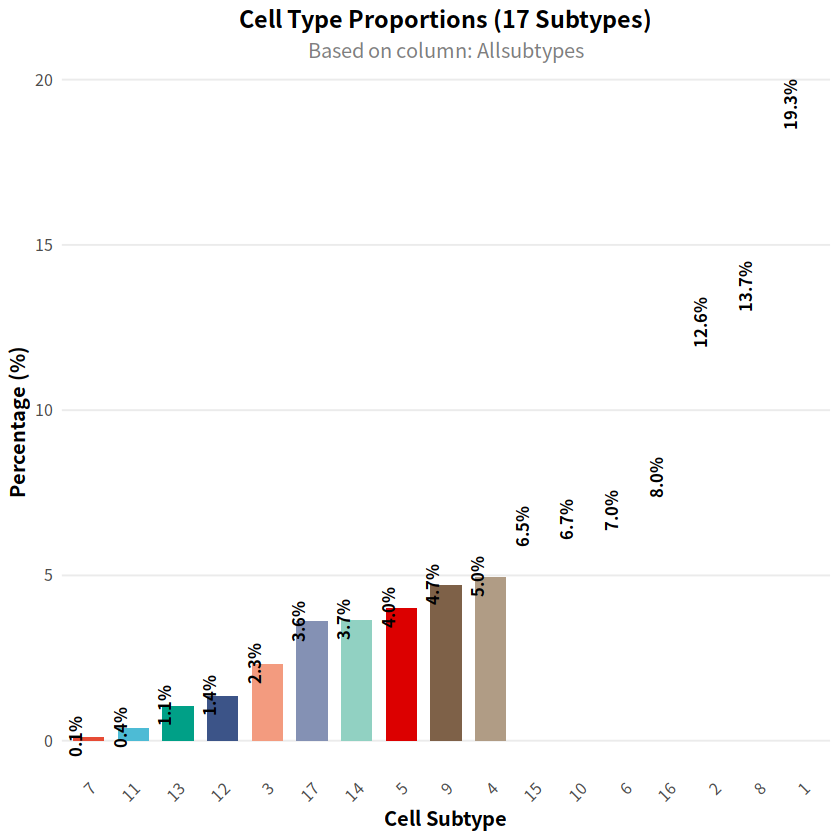

In [5]:
# ==============================================================================
# 1. 加载必要的包 (如果未安装，请先取消注释并运行 install.packages 行)
# ==============================================================================
if (!require("tidyverse")) install.packages("tidyverse")
if (!require("ggsci")) install.packages("ggsci") # 关键：提供丰富的科学配色

library(tidyverse)
library(ggsci)

# ==============================================================================
# 2. 设置文件路径与读取数据
# ==============================================================================
file_path <- "/home/qyyuan/project/Lifei-Spatial/analysis/Part_2_discovery_cohort_CN_definition/Allsubtypes.csv"

# 检查文件是否存在
if (!file.exists(file_path)) {
  stop(paste("错误：找不到文件", file_path))
}

# 读取 CSV (假设第一行是表头)
df <- read.csv(file_path, stringsAsFactors = FALSE, check.names = FALSE)

# 获取最后一列的名称 (即细胞类别列)
target_col <- colnames(df)[ncol(df)]
message(paste("✅ 成功读取文件。检测到细胞类别列为:", target_col))
message(paste("📊 总细胞数:", nrow(df)))
message(paste("🧬 细胞类别数量:", length(unique(df[[target_col]]))))

# ==============================================================================
# 3. 数据处理：计算比例并排序
# ==============================================================================
plot_data <- df %>%
  count(!!sym(target_col)) %>%             # 统计每个类别的数量
  rename(Class = !!sym(target_col)) %>%    # 重命名为 Class 以便统一绘图
  mutate(
    Percentage = n / sum(n) * 100,         # 计算百分比
    # 按百分比从小到大排序因子水平 (绘图时柱子会从左到右递增)
    Class = factor(Class, levels = Class[order(Percentage)]) 
  )

# ==============================================================================
# 4. 绘制柱状图
# ==============================================================================
p <- ggplot(plot_data, aes(x = Class, y = Percentage, fill = Class)) +
  # 绘制柱子
  geom_col(show.legend = FALSE, width = 0.7) +
  
  # 添加百分比标签 (保留1位小数)
  geom_text(aes(label = sprintf("%.1f%%", Percentage)), 
            vjust = -0.5,   # 标签位于柱顶上方
            size = 3.5,     # 字体大小
            angle = 90,     # 垂直显示以防重叠
            color = "black",
            fontface = "bold") +
  
  # 标题和坐标轴标签
  labs(
    title = "Cell Type Proportions (17 Subtypes)",
    subtitle = paste("Based on column:", target_col),
    x = "Cell Subtype",
    y = "Percentage (%)"
  ) +
  
  # 主题美化
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1), # X轴标签倾斜45度
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    plot.subtitle = element_text(hjust = 0.5, color = "gray50"),
    axis.title.y = element_text(face = "bold"),
    axis.title.x = element_text(face = "bold")
  ) +
  
  # 【关键】使用 NPG 调色板 (支持 >17 种颜色，色彩鲜艳且区分度高)
  scale_fill_npg() 

# ==============================================================================
# 5. 显示与保存
# ==============================================================================
print(p)

# 保存为高清图片 (宽12英寸，高7英寸，300 DPI)
output_file <- "cell_type_proportions_17subtypes.png"
ggsave(output_file, plot = p, width = 12, height = 7, dpi = 300, bg = "white")

message(paste("🎉 绘图完成！图片已保存为:", output_file))

In [4]:
# ... [前面的数据处理 plot_data 不变] ...

p <- ggplot(plot_data, aes(x = Class, y = Percentage, fill = Class)) +
  geom_col(show.legend = FALSE, width = 0.7) +
  geom_text(aes(label = sprintf("%.1f%%", Percentage)), 
            vjust = -0.5, size = 3, angle = 90) +
  labs(
    title = paste("Cell Type Proportions (n =", nrow(df), ")"),
    x = "Cell Subtype",
    y = "Percentage (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major.x = element_blank(),
    plot.title = element_text(hjust = 0.5, face = "bold")
  ) +
  # 👇 关键：使用支持 >17 类别的调色板
  scale_fill_npg()  # 来自 ggsci 包

ERROR: Error in scale_fill_npg(): 没有"scale_fill_npg"这个函数


✅ 检测到细胞类别列为: Allsubtypes 
📊 总行数: 1717465 
🧬 发现细胞类别数量: 17 
🎨 已生成 17 种鲜明颜色。


Warning message in geom_col(width = 0.7, color = "white", size = 0.2):
“Ignoring unknown parameters: `size`”



🎉 成功！图片已保存为: cell_types_colored_fixed.png 
💡 提示：如果颜色仍然不满意，可以修改代码中的 'palette' 参数尝试 'Set 2', 'Vivid', 或 'Dynamic'。


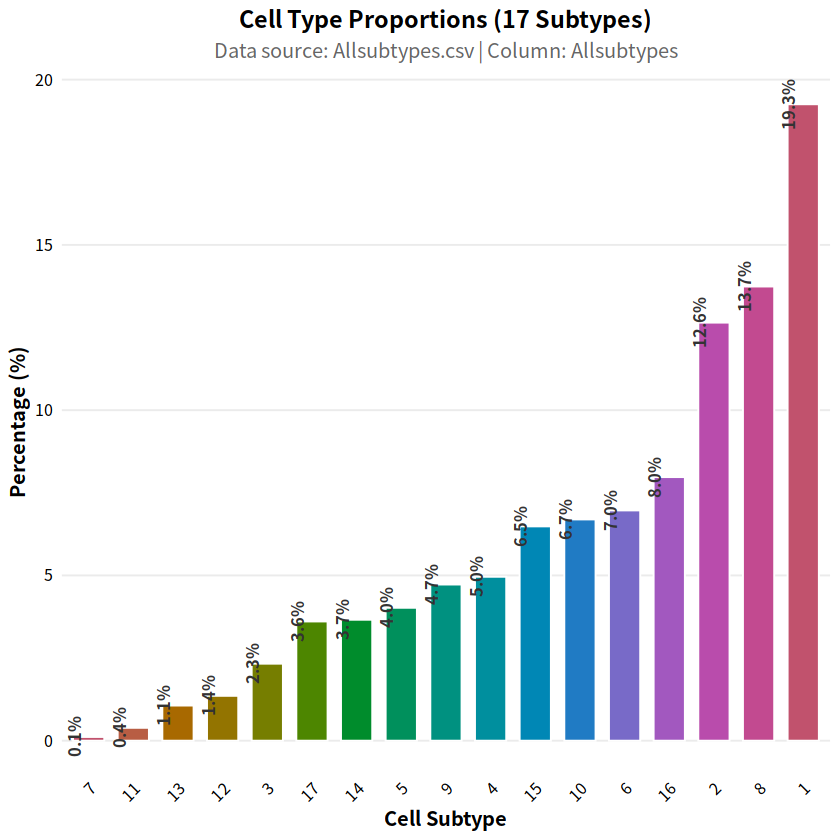

In [6]:
# ==============================================================================
# 1. 加载必要的包
# ==============================================================================
# 如果未安装，请取消下面两行的注释并运行一次
# install.packages("tidyverse")
# install.packages("colorspace") 

library(tidyverse)
library(colorspace) # 用于生成高质量的专业配色

# ==============================================================================
# 2. 设置文件路径与读取数据
# ==============================================================================
file_path <- "/home/qyyuan/project/Lifei-Spatial/analysis/Part_2_discovery_cohort_CN_definition/Allsubtypes.csv"

# 检查文件是否存在
if (!file.exists(file_path)) {
  stop(paste("❌ 错误：找不到文件 ->", file_path))
}

# 读取数据
df <- read.csv(file_path, stringsAsFactors = FALSE, check.names = FALSE)

# 自动获取最后一列的列名
target_col <- colnames(df)[ncol(df)]
cat(paste("✅ 检测到细胞类别列为:", target_col, "\n"))
cat(paste("📊 总行数:", nrow(df), "\n"))

# 获取唯一的类别列表
unique_classes <- unique(df[[target_col]])
n_classes <- length(unique_classes)
cat(paste("🧬 发现细胞类别数量:", n_classes, "\n"))

if (n_classes == 0) stop("❌ 未找到任何细胞类别数据。")

# ==============================================================================
# 3. 数据处理：计算比例
# ==============================================================================
plot_data <- df %>%
  count(!!sym(target_col)) %>%
  rename(Class = !!sym(target_col)) %>%
  mutate(
    Percentage = n / sum(n) * 100,
    # 按百分比从小到大排序，让图表更有序
    Class = factor(Class, levels = Class[order(Percentage)])
  )

# ==============================================================================
# 4. 【核心修复】生成 17 种鲜明且不重复的颜色
# ==============================================================================
# 使用 colorspace 的 qualitative_hcl 生成高区分度的定性色
# h = 色调, c = 彩度 (越高越鲜艳), l = 亮度
my_colors <- qualitative_hcl(n = n_classes, palette = "Dark 3", 
                             h = c(0, 360), c = 75, l = 50)

# 如果生成的颜色数量不够（极端情况），手动补充一些高亮色
if (length(my_colors) < n_classes) {
  extra_colors <- c("#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00", 
                    "#FFFF33", "#A65628", "#F781BF", "#999999", "#66C2A5",
                    "#FC8D62", "#8DA0CB", "#E78AC3", "#A6D854", "#FFD92F",
                    "#E5C494", "#B3B3B3")
  my_colors <- c(my_colors, extra_colors)[1:n_classes]
}

cat(paste("🎨 已生成", length(my_colors), "种鲜明颜色。\n"))

# ==============================================================================
# 5. 绘图
# ==============================================================================
p <- ggplot(plot_data, aes(x = Class, y = Percentage, fill = Class)) +
  geom_col(width = 0.7, color = "white", size = 0.2) + # 添加白色细边框，增加区分度
  
  # 添加数值标签
  geom_text(aes(label = sprintf("%.1f%%", Percentage)), 
            vjust = -0.6,   # 稍微向上提一点
            size = 3.5, 
            angle = 90,     # 垂直文字
            fontface = "bold",
            color = "#333333") +
  
  labs(
    title = "Cell Type Proportions (17 Subtypes)",
    subtitle = paste("Data source:", basename(file_path), "| Column:", target_col),
    x = "Cell Subtype",
    y = "Percentage (%)"
  ) +
  
  # 应用我们手动生成的鲜明颜色
  scale_fill_manual(values = my_colors, name = "Cell Type") +
  
  theme_minimal(base_size = 12) +
  theme(
    # X轴标签旋转45度，防止重叠
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, color = "black"),
    axis.text.y = element_text(color = "black"),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14, color = "black"),
    plot.subtitle = element_text(hjust = 0.5, color = "gray40"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "none" # 隐藏图例，因为X轴已有标签
  )

# ==============================================================================
# 6. 显示与保存
# ==============================================================================
print(p)

# 保存为高分辨率 PNG
output_name <- "cell_types_colored_fixed.png"
ggsave(output_name, plot = p, width = 14, height = 8, dpi = 300, bg = "white")

cat(paste("\n🎉 成功！图片已保存为:", output_name, "\n"))
cat("💡 提示：如果颜色仍然不满意，可以修改代码中的 'palette' 参数尝试 'Set 2', 'Vivid', 或 'Dynamic'。\n")